In [5]:
import numpy as np
from pymbar.timeseries import detect_equilibration
import matplotlib.pyplot as plt

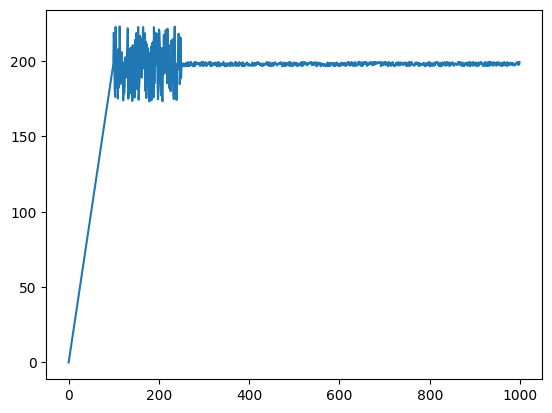

In [27]:
X=np.arange(0, 1000)

Y=np.zeros(len(X))
for i in range(len(X)):
    if(i<100):
        Y[i]=2*i
    elif(i>=100 and i<250):
        Y[i]=198+(np.random.rand()-0.5)*50
    else:
        Y[i]=198+(np.random.rand()-0.5)*3
plt.plot(X, Y)

In [28]:
"""
Procedure: Find the t_eq in the first place, and then find the ACF decay time
Once that thing is available, use the Criterion to judge if the things have actually converged or not
Then take the average of all block averages, and take the SE of the the blocks
Here, we'll divide our artificial data into certain parts to do the analysis, first, we'll just take the initial, say 100 points, then maybe 400, and then full
"""
D1_X=X[:100]
D1_Y=Y[:100]

D2_X=X[:400]
D2_Y=Y[:400]

D3_X=X
D3_Y=Y

from pymbar.timeseries import detect_equilibration
t1, g1, N1=detect_equilibration(D1_Y)
print(len(D1_Y))
print(t1, g1, N1)
if(t1>=0.5*len(D1_Y) or N1<100):
    print("D1 hasn't converged yet!")

t2, g2, N2=detect_equilibration(D2_Y)
tau2=(g2-1)/2
print(len(D2_Y))
print(t2, g2, N2)
if(t2>=0.5*len(D2_Y) or N2<100):
    print("D2 hasn't converged yet!")
else:
    print("Maybe D2 converged, but we'll do block invariance")

t3, g3, N3=detect_equilibration(D3_Y)
tau3=(g3-1)/2                                                               #g=1+2*tau, tau=Decay time of the CF
print(len(D3_Y))
print(t3, g3, N3)
if(t3>=0.5*len(D3_Y) or N3<100):
    print("D3 hasn't converged yet")
else:
    print("Maybe D3 converged, but we'll do block invariance")

print(tau2, tau3) #<--Here the tau values are zero, how do we set the blocks then? As a std practice, choose the minimum number of blocks=5

100
96 1.0 5.0
D1 hasn't converged yet!
400
89 1.0 312.0
Maybe D2 converged, but we'll do block invariance
1000
89 1.0 912.0
Maybe D3 converged, but we'll do block invariance
0.0 0.0


In [29]:
D2_Y_pr=D2_Y[t2:]
D2_X_pr=D2_X[t2:]

D3_Y_pr=D3_Y[t3:]
D3_X_pr=D3_X[t3:]

def block_invariance(block_ps, data):
    nblocks=int(len(data)/block_ps)
    mu_X=np.zeros(nblocks)
    for i in range(nblocks):
        mu_X[i]=np.mean(data[i*block_ps:(i+1)*block_ps])
    se_x=np.std(mu_X, ddof=1)/np.sqrt(nblocks)
    return se_x, mu_X

tau2_5=int(len(D2_Y_pr)/5)
tau2_10=int(len(D2_Y_pr)/10)
tau2_20=int(len(D2_Y_pr)/20)
se2_5, mu2_5=block_invariance(tau2_5, D2_Y_pr)
se2_10, mu2_10=block_invariance(tau2_10, D2_Y_pr)
se2_20, mu2_20=block_invariance(tau2_20, D2_Y_pr)
print(se2_5, se2_10, se2_20)
if(np.abs((se2_10-se2_20)/se2_20)<1/(np.sqrt(2*(10-1)))):
    print("D2 has converged")
else:
    print("D2 is not good enough")
print("For D2: ", np.abs((se2_10-se2_20)/se2_20), 1/(np.sqrt(2*(10-1))))

tau3_5=int(len(D3_Y_pr)/5)
tau3_10=int(len(D3_Y_pr)/10)
tau3_20=int(len(D3_Y_pr)/20)
se3_5, mu3_5=block_invariance(tau3_5, D3_Y_pr)
se3_10, mu3_10=block_invariance(tau3_10, D3_Y_pr)
se3_20, mu3_20=block_invariance(tau3_20, D3_Y_pr)
print(se3_5, se3_10, se3_20)
if(np.abs((se3_10-se3_20)/se3_20)<1/(np.sqrt(2*(10-1)))):
    print("D3 has converged")
else:
    print("D3 is not good enough")
print("For D3: ", np.abs((se3_10-se3_20)/se3_20), 1/(np.sqrt(2*(10-1))))

0.7320250454411513 0.4955643293124358 0.6637336841667795
D2 is not good enough
For D2:  0.25336872131999094 0.23570226039551587
0.1494348526057905 0.25903744003065915 0.24205850964283468
D3 has converged
For D3:  0.07014391030035441 0.23570226039551587
